In [1]:
import kagglehub
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import prep_logs

logs = prep_logs.get_sleep_data()
sns.set_theme()

# Data preparation methodology

Future methods of processing the data depends on given sources. There will be presented data from two distinct tables of different formats: **markdown** - `.md`, and **comma-separated values (CSV)** - `.txt` or `.csv`. The data of these sources must follow common table structure for future processing and interpreting. That's why these files will undergo several stages of the preparatory process, **scv-source** table's format chosen as more preferable due it's data precision:

1. Fetching **markdown** table by title (source code `md_extract`):
   This is performed in `md_extract.py` by using such packages as [Markdown](https://pypi.org/project/Markdown/) and [Beautiful Soup](https://pypi.org/project/beautifulsoup4/);
4. Renaming columns of the **md-source** table to match the names of the **csv-source** table;
5. Adding new and removing unnecessry columns to the **md-source** for compatibility with **csv-source**;
6. Changing `Duration` column to timestamp to make it easier to operate with;
7. Generate dates for rows, **md-source** has data aranged sequentially in ascending date order.
   The earliest day of the **csv_source** used for generation;
8. Formatting **Sleep Time** and **Wake Time** of the both tables.
9. Finallization: tables concatination and setting dtypes.

# Table verification

In [2]:
logs

,Sleep Time,Wake Time,Duration,Notes
0,2025-10-16 05:21:00,2025-10-16 09:55:00,0 days 04:34:00,NaN
1,2025-10-17 01:10:00,2025-10-17 09:00:00,0 days 07:50:00,NaN
2,2025-10-18 00:35:00,2025-10-18 08:05:00,0 days 07:30:00,NaN
3,2025-10-18 23:00:00,2025-10-19 07:50:00,0 days 08:50:00,NaN
4,2025-10-19 23:00:00,2025-10-20 07:00:00,0 days 08:00:00,NaN
...,...,...,...,...
62,2025-12-16 22:24:00,2025-12-17 06:00:00,0 days 07:36:00,"Woke up easily, no any discomfort."
63,2025-12-17 22:48:00,2025-12-18 06:15:00,0 days 07:27:00,Bad sleep. I felt dehydrated all night. Slight...
64,2025-12-18 22:50:00,2025-12-19 06:10:00,0 days 07:20:00,Slept well.
65,2025-12-19 22:48:00,2025-12-20 06:20:00,0 days 07:32:00,Slept well. Hard to wake up.


In [3]:
logs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype          
---  ------      --------------  -----          
 0   Sleep Time  67 non-null     datetime64[ns] 
 1   Wake Time   67 non-null     datetime64[ns] 
 2   Duration    67 non-null     timedelta64[ns]
 3   Notes       41 non-null     object         
dtypes: datetime64[ns](2), object(1), timedelta64[ns](1)
memory usage: 2.2+ KB


# Time variability

<Axes: xlabel='Sleep Time'>

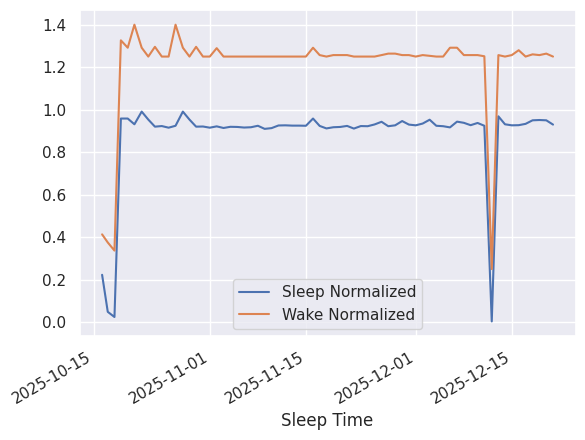

In [4]:
def normalize(s):
    s = s - pd.to_datetime(logs['Sleep Time'].dt.date)
    s = s / pd.to_timedelta('1 days')
    return s
logs[['Sleep Normalized', 'Wake Normalized']] = logs[['Sleep Time', 'Wake Time']].apply(normalize)
logs[['Sleep Time', 'Sleep Normalized', 'Wake Normalized']].plot(x='Sleep Time')

In [5]:
logs['Sleep Time']

0    2025-10-16 05:21:00
1    2025-10-17 01:10:00
2    2025-10-18 00:35:00
3    2025-10-18 23:00:00
4    2025-10-19 23:00:00
             ...        
62   2025-12-16 22:24:00
63   2025-12-17 22:48:00
64   2025-12-18 22:50:00
65   2025-12-19 22:48:00
66   2025-12-20 22:19:00
Name: Sleep Time, Length: 67, dtype: datetime64[ns]

# Weekly mean durations

<Axes: xlabel='Sleep Time'>

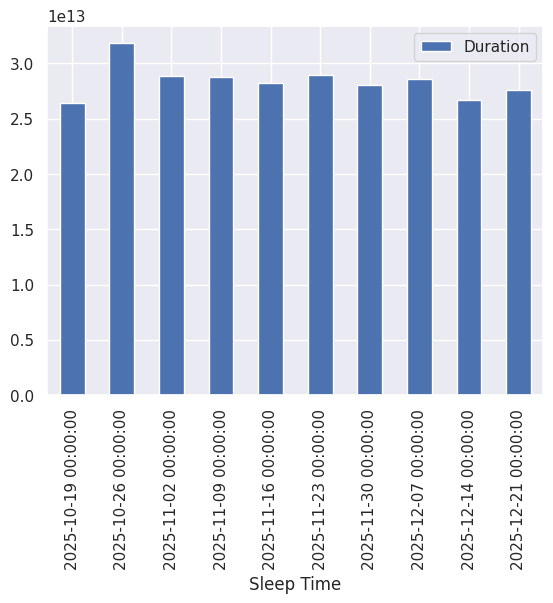

In [6]:
# Prepare
to_hours = lambda td: td.seconds / 3600

(
    logs[['Sleep Time', 'Duration']]
    .resample('W', on='Sleep Time')
    .mean()
    .plot(kind='bar')
)


<Axes: >

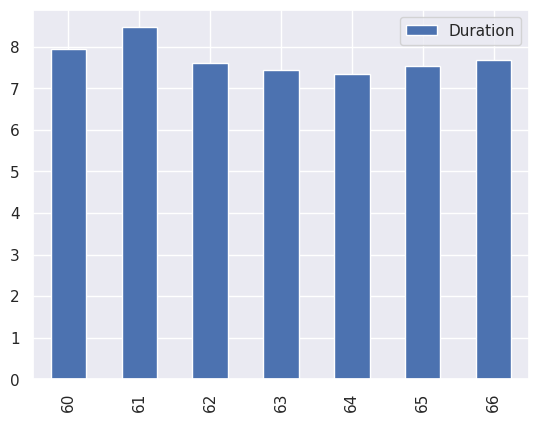

In [7]:
# Prepare
(
    logs[['Duration']]
    .tail(7)
    .map(to_hours)
    .plot(kind='bar')
)

# Durations per weekday

<Axes: xlabel='Day', ylabel='Duration'>

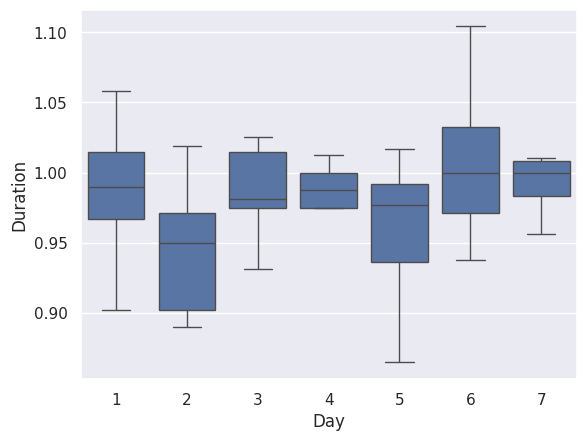

In [8]:
data = logs['Duration'].apply(lambda v: v/ pd.to_timedelta('8h')).to_frame()
data['Day'] = logs['Sleep Time'].dt.isocalendar().day

sns.boxplot(
    data=data,
    x='Day',
    y='Duration',
    showfliers=False,
)

# References

- [Markdown Official Website](https://daringfireball.net/projects/markdown/)
- [Beautiful Soup Official Website](https://www.crummy.com/software/BeautifulSoup/)
- [Markdown in PyPI](https://pypi.org/project/Markdown/)
- [Beautiful Soup in PyPI](https://pypi.org/project/beautifulsoup4/)